# Car Prediction

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")


In [2]:
df=pd.read_csv("Car.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC


# EDA

In [3]:
df.shape

(8128, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           8128 non-null   object
 1   year           8128 non-null   int64 
 2   selling_price  8128 non-null   int64 
 3   km_driven      8128 non-null   int64 
 4   fuel           8128 non-null   object
 5   seller_type    8128 non-null   object
 6   transmission   8128 non-null   object
 7   owner          8128 non-null   object
 8   mileage        7907 non-null   object
 9   engine         7907 non-null   object
dtypes: int64(3), object(7)
memory usage: 635.1+ KB


In [5]:
df.describe()

,year,selling_price,km_driven
count,8128.000000,8.128000e+03,8.128000e+03
mean,2013.804011,6.382718e+05,6.981951e+04
std,4.044249,8.062534e+05,5.655055e+04
min,1983.000000,2.999900e+04,1.000000e+00
25%,2011.000000,2.549990e+05,3.500000e+04
50%,2015.000000,4.500000e+05,6.000000e+04
75%,2017.000000,6.750000e+05,9.800000e+04
max,2020.000000,1.000000e+07,2.360457e+06


In [6]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1202)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(6926, 10)

In [10]:
df["mileage"]=df["mileage"].str.split(" ").str[0]
df["engine"]=df["engine"].str.split(" ").str[0]
df[["mileage","engine"]]=df[["mileage","engine"]].astype(float)

df.head()



,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0


In [11]:
df.describe()

,year,selling_price,km_driven,mileage,engine
count,6926.000000,6.926000e+03,6.926000e+03,6718.00000,6718.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.46531,1430.891337
std,4.078286,5.197670e+05,5.835810e+04,4.04915,493.493277
min,1983.000000,2.999900e+04,1.000000e+00,0.00000,624.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.80000,1197.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.44000,1248.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.50000,1498.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.00000,3604.000000


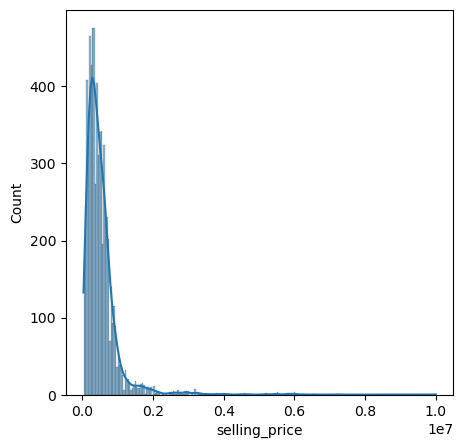

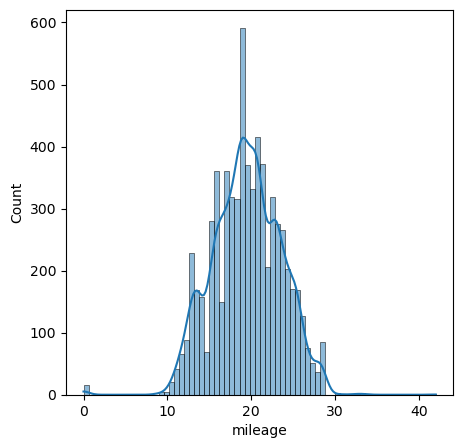

In [12]:
cols=df[["selling_price","mileage"]]

for col in cols:
    plt.figure(figsize=(5,5))
    sns.histplot(x=df[col],kde=True)

<Axes: xlabel='engine'>

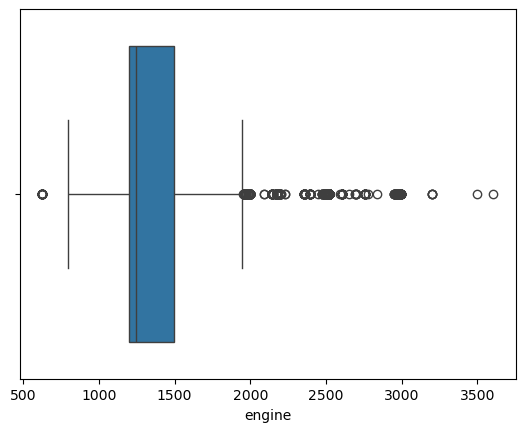

In [13]:
sns.boxplot(x=df["engine"])

## Cleaning

In [14]:
df["mileage"]=df["mileage"].fillna(df.groupby("name")["mileage"].transform("median"))
df["engine"]=df["engine"].fillna(df.groupby("name")["engine"].transform("median"))

#fill remaining NAN

df["mileage"]=df["mileage"].fillna(df["mileage"].median())
df["engine"]=df["engine"].fillna(df["engine"].median())




df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   object 
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   object 
 5   seller_type    6926 non-null   object 
 6   transmission   6926 non-null   object 
 7   owner          6926 non-null   object 
 8   mileage        6926 non-null   float64
 9   engine         6926 non-null   float64
dtypes: float64(2), int64(3), object(5)
memory usage: 595.2+ KB


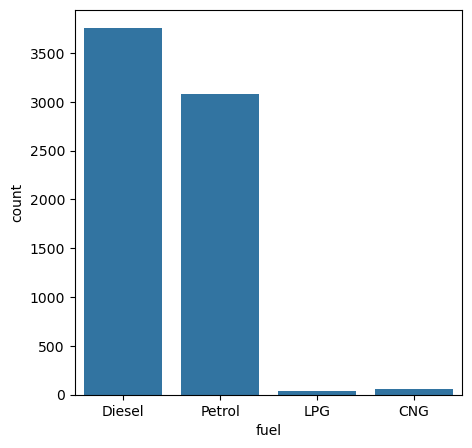

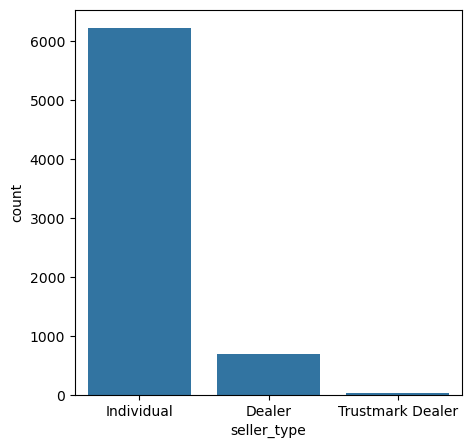

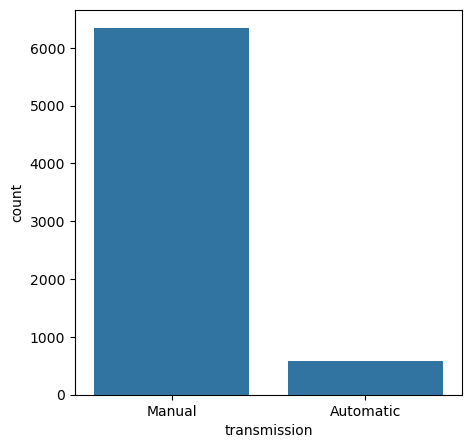

In [15]:
cols=df[["fuel","seller_type","transmission",]]

for col in cols:
    plt.figure(figsize=(5,5))
    sns.countplot(x=df[col])

<Axes: xlabel='engine', ylabel='selling_price'>

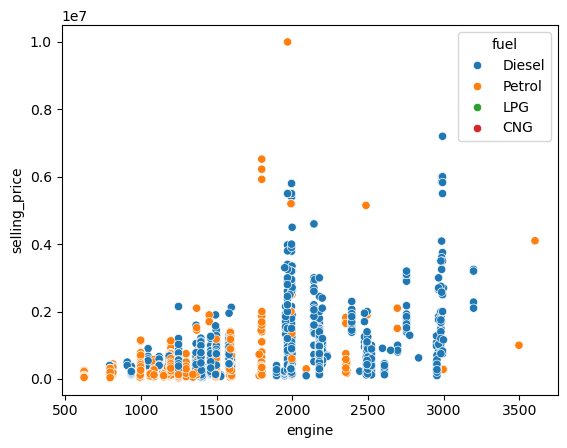

In [16]:
sns.scatterplot(x="engine",y="selling_price",data =df,hue="fuel")

In [17]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0


## Feature Engineering

In [18]:
df["car_age"]=2026-df["year"]
df.drop("year",axis=1,inplace=True)
df.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,car_age
0,Maruti Swift Dzire VDI,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,12
1,Skoda Rapid 1.5 TDI Ambition,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,12
2,Honda City 2017-2020 EXi,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,20
3,Hyundai i20 Sportz Diesel,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,16
4,Maruti Swift VXI BSIII,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,19


In [19]:
df["brand"]=df["name"].str.split(" ").str[0]
df.drop("name",axis=1,inplace=True)
df.head()


,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,car_age,brand
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,12,Maruti
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,12,Skoda
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,20,Honda
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,16,Hyundai
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,19,Maruti


<Axes: xlabel='selling_price'>

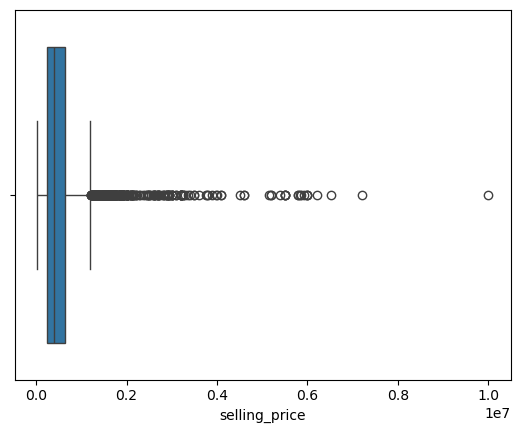

In [20]:
sns.boxplot(x=df["selling_price"])

<Axes: xlabel='km_driven'>

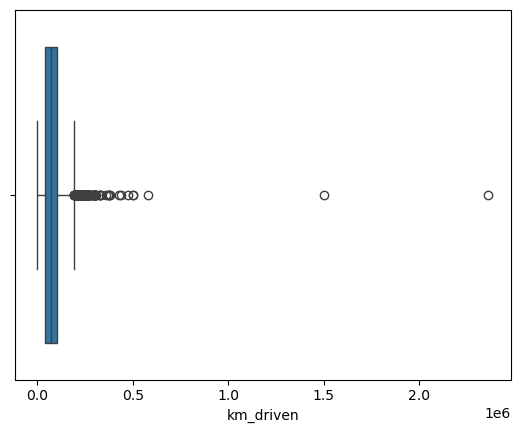

In [21]:
sns.boxplot(x=df["km_driven"])

<Axes: >

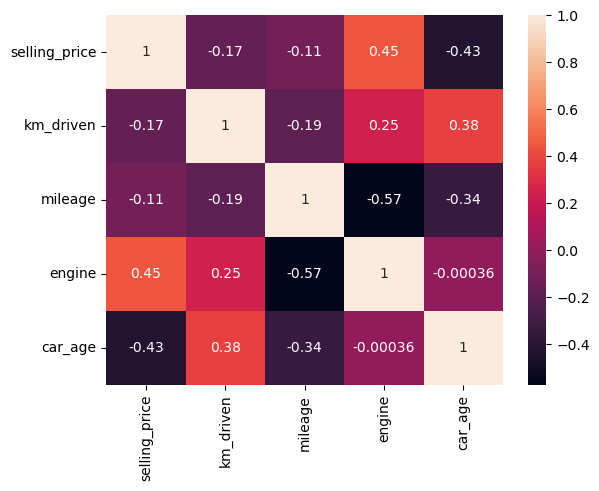

In [22]:

sns.heatmap(df.select_dtypes(include="number").corr(),annot=True)

In [23]:
df=df[(df["selling_price"]>50000) & (df["km_driven"]>100) & (df["km_driven"]<400000)]
df.shape

(6847, 10)

<Axes: xlabel='selling_price'>

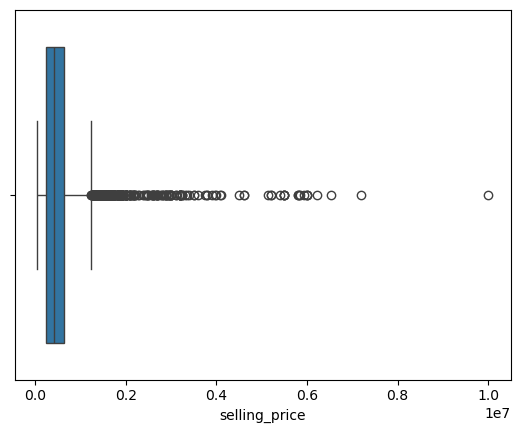

In [24]:
sns.boxplot(x=df["selling_price"])

## Encoding

In [25]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,car_age,brand
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,12,Maruti
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,12,Skoda
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,20,Honda
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,16,Hyundai
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,19,Maruti


In [26]:
df["owner"]=df["owner"].map({"First Owner":1,"Second Owner":2,"Third Owner":3,"Fourth & Above Owner":4,"Test Drive Car":0})


In [27]:
brand_count=df["brand"].value_counts()
rare_brands=brand_count[brand_count<10].index

df["brand"]=df["brand"].replace(rare_brands,"Others")



In [28]:
df=pd.get_dummies(df,columns=["fuel","seller_type","transmission","brand"],drop_first=True,dtype=int)
df.head()

,selling_price,km_driven,owner,mileage,engine,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,...,brand_Maruti,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Others,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,450000,145500,1,23.40,1248.0,12,1,0,0,1,...,1,0,0,0,0,0,0,0,0,0
1,370000,120000,2,21.14,1498.0,12,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,158000,140000,3,17.70,1497.0,20,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
3,225000,127000,1,23.00,1396.0,16,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,130000,120000,1,16.10,1298.0,19,0,0,1,1,...,1,0,0,0,0,0,0,0,0,0


## Train Test Split

In [31]:
X=df.drop("selling_price",axis=1)
y=df["selling_price"]


In [32]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)